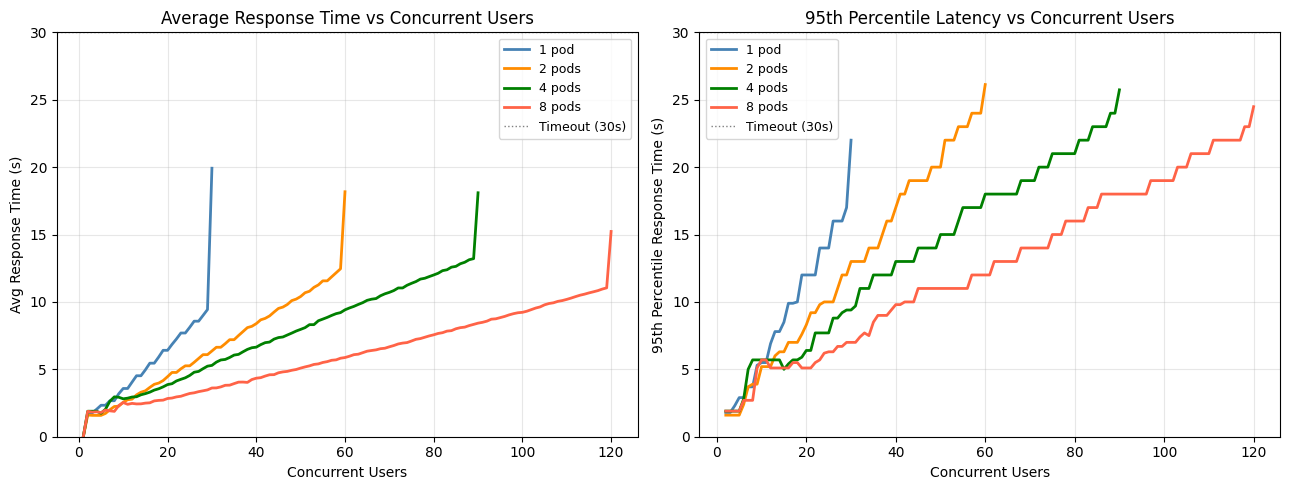

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

configs = {
    '1 pod':  'results/1pod_stats_history.csv',
    '2 pods': 'results/2pod_stats_history.csv',
    '4 pods': 'results/4pod_stats_history.csv',
    '8 pods': 'results/8pod_stats_history.csv',
}
colors = ['steelblue', 'darkorange', 'green', 'tomato']

def load_history(path, value_col):
    df = pd.read_csv(path)
    df = df[(df['Name'] == 'Aggregated') & (df['User Count'] > 0)]
    df = df.replace('N/A', float('nan')).dropna(subset=[value_col])
    df[value_col] = pd.to_numeric(df[value_col])
    # trim breaking point spikes (artifact from timeouts)
    df = df[df[value_col] < 28000]
    grouped = df.groupby('User Count')[value_col].mean() / 1000  # ms → s
    return grouped

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Average Response Time
for (label, path), color in zip(configs.items(), colors):
    s = load_history(path, 'Total Average Response Time')
    axes[0].plot(s.index, s.values, '-', color=color, linewidth=2, label=label)
axes[0].axhline(y=30, color='gray', linestyle=':', linewidth=1, label='Timeout (30s)')
axes[0].set_xlabel('Concurrent Users')
axes[0].set_ylabel('Avg Response Time (s)')
axes[0].set_title('Average Response Time vs Concurrent Users')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 40)

# Plot 2: 95th Percentile Response Time
for (label, path), color in zip(configs.items(), colors):
    s = load_history(path, '95%')
    axes[1].plot(s.index, s.values, '-', color=color, linewidth=2, label=label)
axes[1].axhline(y=30, color='gray', linestyle=':', linewidth=1, label='Timeout (30s)')
axes[1].set_xlabel('Concurrent Users')
axes[1].set_ylabel('95th Percentile Response Time (s)')
axes[1].set_title('95th Percentile Latency vs Concurrent Users')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 40)

plt.tight_layout()
plt.savefig('../benchmark_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
!pip list | grep numpy

numpy                       2.4.4
